# Bulk RNA-seq Data Analysis Workflow in Python

## Import Required Libraries

In [62]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import zscore
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

## Load the Count Data

In [63]:

if not os.path.exists("data/kallisto.merged.gene_counts.tsv"):
    
    !mkdir -p data; 

    !cd data; wget https://github.com/BMGLab/CrashCourses/raw/refs/heads/main/data/kallisto.merged.gene_counts.tsv.gz

    !gunzip data/kallisto.merged.gene_counts.tsv.gz
    !mkdir -p write

if not os.path.exists("data/SraRunTable_SRP428267.csv"):
    !cd data; wget https://raw.githubusercontent.com/BMGLab/CrashCourses/refs/heads/main/SraRunTable_SRP428267.csv


--2025-01-18 20:44:59--  https://github.com/BMGLab/CrashCourses/raw/refs/heads/main/data/kallisto.merged.gene_counts.tsv.gz
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/BMGLab/CrashCourses/refs/heads/main/data/kallisto.merged.gene_counts.tsv.gz [following]
--2025-01-18 20:44:59--  https://raw.githubusercontent.com/BMGLab/CrashCourses/refs/heads/main/data/kallisto.merged.gene_counts.tsv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3644467 (3.5M) [application/octet-stream]
Saving to: ‘kallisto.merged.gene_counts.tsv.gz’

kallisto.merged.gen 100%[===================>]   3.48M  3.19MB/s    

In [86]:
meta_data = pd.read_csv("data/SraRunTable_SRP428267.csv", index_col=0)
meta_data.head()

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Collection_Date,Consent,...,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,tissue,treatment,type
Run,,,,,,,,,,,,,,,,,,,,,
SRR23920135,RNA-Seq,300,17246491200,PRJNA946733,SAMN33830924,5485957628,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:13:00Z,1,GSM7106614,blood,SRP428267,blood,TRAIL and IL-10 treated macrophages (TRAIL+M2c...,M2
SRR23920136,RNA-Seq,300,14616309300,PRJNA946733,SAMN33830925,4675314188,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:06:00Z,1,GSM7106613,blood,SRP428267,blood,IL-10 treated macrophages (M2c polarized),M2
SRR23920137,RNA-Seq,300,14613659100,PRJNA946733,SAMN33830926,4660748932,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:15:00Z,1,GSM7106612,blood,SRP428267,blood,TRAIL and IL-4 treated macrophages (TRAIL+M2a ...,M2
SRR23920138,RNA-Seq,300,19873255200,PRJNA946733,SAMN33830927,6315539862,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:30:00Z,1,GSM7106611,blood,SRP428267,blood,IL-4 treated macrophages (M2a polarized),M2
SRR23920139,RNA-Seq,300,17879225700,PRJNA946733,SAMN33830928,5722839665,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:07:00Z,1,GSM7106610,blood,SRP428267,blood,TRAIL treated macrophages,Mac


In [87]:
meta_data['treatment'].value_counts()


treatment
TRAIL and IL-10 treated macrophages (TRAIL+M2c polarized)           4
IL-10 treated macrophages (M2c polarized)                           4
TRAIL and IL-4 treated macrophages (TRAIL+M2a polarized)            4
IL-4 treated macrophages (M2a polarized)                            4
TRAIL treated macrophages                                           4
untreated/unpolarized macrophages (M0)                              4
TRAIL and LPS+IFN gamma treated macrophages (TRAIL+M1 polarized)    3
LPS+IFN gamma treated macrophages (M1 polarized)                    3
Name: count, dtype: int64

In [88]:
# Example: Load count data from a CSV file
count_data = pd.read_csv("data/kallisto.merged.gene_counts.tsv", sep='\t', index_col=0)
count_data.head()

,gene_name,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,2.02176,3.727665,4.063680,1.09191,6.124644,2.089881,7.19256,3.132604,14.26759,...,5.069734,10.03710,6.170962,12.13151,11.348137,6.181133,6.65294,13.311949,7.06168,12.79485
ENSG00000000005,TNMD,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.00000,0.00000
ENSG00000000419,DPM1,1314.00080,1247.001100,1280.002890,1788.00089,1387.995250,975.999840,1155.00100,1286.000900,1890.99622,...,1140.000300,1222.00324,1364.001150,1578.00515,1358.000640,1271.000170,1567.99910,1151.999970,1042.00000,1185.00001
ENSG00000000457,SCYL3,610.95232,527.982500,463.005201,648.64228,579.150000,903.586700,682.04930,557.254800,609.93535,...,738.204200,417.46375,610.624000,711.61850,555.402500,409.202730,614.58860,1135.183200,935.56240,519.05481
ENSG00000000460,C1orf112,331.58162,320.063210,275.908750,365.19616,303.405310,136.319020,145.46600,329.844380,397.55423,...,194.538080,306.60342,306.384330,360.29630,261.901080,259.075120,290.22652,200.400691,180.83710,317.87167


In [89]:
#Store the gene_symbols and save it for later. Always, use the Ensemble Gene IDs when working with large datasets.
gene_symbols = count_data['gene_name']
gene_symbols.head()

gene_id
ENSG00000000003      TSPAN6
ENSG00000000005        TNMD
ENSG00000000419        DPM1
ENSG00000000457       SCYL3
ENSG00000000460    C1orf112
Name: gene_name, dtype: object

In [90]:
#Drop the very first column (gene_name) from the dataframe
count_data = count_data.drop(columns='gene_name')
#round up to integers
count_data = count_data.round().astype(int) 
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288584,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000288585,2,1,0,4,2,9,4,0,0,0,...,8,3,0,0,0,0,0,6,4,0
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


## Normalize data and filter low expressed genes

In [100]:
count_data.index[count_data.sum(axis=1) >= 100]

Index(['ENSG00000000003', 'ENSG00000000419', 'ENSG00000000457',
       'ENSG00000000460', 'ENSG00000000938', 'ENSG00000000971',
       'ENSG00000001036', 'ENSG00000001084', 'ENSG00000001167',
       'ENSG00000001460',
       ...
       'ENSG00000288568', 'ENSG00000288569', 'ENSG00000288573',
       'ENSG00000288577', 'ENSG00000288579', 'ENSG00000288580',
       'ENSG00000288582', 'ENSG00000288586', 'ENSG00000288587',
       'ENSG00000288588'],
      dtype='object', name='gene_id', length=22910)

In [104]:
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288584,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
ENSG00000288585,2,1,0,4,2,9,4,0,0,0,...,8,3,0,0,0,0,0,6,4,0
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


Filter genes with less than 100 read counts across all samples

In [109]:
count_data = count_data[count_data.sum(axis=1) >= 100]
count_data

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,2,4,4,1,6,2,7,3,14,20,...,5,10,6,12,11,6,7,13,7,13
ENSG00000000419,1314,1247,1280,1788,1388,976,1155,1286,1891,1732,...,1140,1222,1364,1578,1358,1271,1568,1152,1042,1185
ENSG00000000457,611,528,463,649,579,904,682,557,610,590,...,738,417,611,712,555,409,615,1135,936,519
ENSG00000000460,332,320,276,365,303,136,145,330,398,347,...,195,307,306,360,262,259,290,200,181,318
ENSG00000000938,13972,11458,8685,13531,16645,7655,7160,13411,29568,22139,...,11531,24542,23167,20767,16198,19315,22180,16804,12891,21294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288580,4,6,5,5,8,0,4,9,7,2,...,1,3,3,3,4,2,0,5,3,3
ENSG00000288582,40,31,45,72,57,41,15,61,17,8,...,13,12,21,20,14,41,22,22,21,17
ENSG00000288586,70,59,22,46,47,4,13,66,49,59,...,13,74,65,54,65,20,70,24,20,53


In [91]:
def tpm_normalization(counts):
    gene_lengths = counts.sum(axis=1)
    scaled_counts = counts.div(gene_lengths, axis=0)
    tpm = scaled_counts.div(scaled_counts.sum(axis=0), axis=1) * 1e6
    return tpm

normalized_data = tpm_normalization(count_data)
normalized_data.head()

,SRR23920135,SRR23920136,SRR23920137,SRR23920138,SRR23920139,SRR23920140,SRR23920141,SRR23920142,SRR23920143,SRR23920144,...,SRR23920155,SRR23920156,SRR23920157,SRR23920158,SRR23920159,SRR23920160,SRR23920161,SRR23920162,SRR23920163,SRR23920164
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,4.041227,9.068228,8.568241,1.616767,10.145270,5.475493,18.546647,5.653952,28.526546,43.367821,...,14.818537,28.607152,12.305651,24.586352,26.784013,14.226099,14.112894,28.515831,19.617565,28.147785
ENSG00000000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000000419,18.824556,20.043566,19.439618,20.495614,16.639793,18.944761,21.696788,17.183749,27.318621,26.627573,...,23.954454,24.785171,19.834159,22.922709,23.443844,21.366147,22.413527,17.916008,20.704315,18.191366
ENSG00000000457,20.317765,19.699164,16.321651,17.268056,16.111737,40.729875,29.737413,17.275773,20.455138,21.054312,...,35.995079,19.631890,20.622721,24.007352,22.239621,15.959134,20.405376,40.972264,43.169233,18.493523
ENSG00000000460,23.137916,25.021612,20.391239,20.353685,17.670867,12.842069,13.250682,21.451006,27.970941,25.951947,...,19.933006,30.291157,21.645998,25.440064,22.003264,21.180549,20.165960,15.131275,17.495586,23.748209


## Differential Expression Analysis Using DESeq2

### Prepare input for DESeq2

In [70]:
#To check the samples only M1 polarization: 
meta_data[meta_data['type'] == "M1"]

,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,cell_type,Center Name,Collection_Date,Consent,...,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,tissue,treatment,type
Run,,,,,,,,,,,,,,,,,,,,,
SRR23920141,RNA-Seq,300,15706026000,PRJNA946733,SAMN33830930,5026508919,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:25:00Z,1,GSM7106608,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1
SRR23920154,RNA-Seq,300,14640228300,PRJNA946733,SAMN33830943,4649122076,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:19:00Z,1,GSM7106595,blood,SRP428267,blood,TRAIL and LPS+IFN gamma treated macrophages (T...,M1
SRR23920155,RNA-Seq,300,14943025800,PRJNA946733,SAMN33830944,4745957976,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:20:00Z,1,GSM7106594,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1
SRR23920162,RNA-Seq,300,17836350900,PRJNA946733,SAMN33830951,5678818309,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:27:00Z,1,GSM7106587,blood,SRP428267,blood,TRAIL and LPS+IFN gamma treated macrophages (T...,M1
SRR23920163,RNA-Seq,300,14241193200,PRJNA946733,SAMN33830952,4513798775,primary human monocyte derived macrophages,IZMIR BIOMEDICINE AND GENOME CENTER,missing,public,...,ILLUMINA,2023-09-11T00:00:00Z,2023-03-20T18:18:00Z,1,GSM7106586,blood,SRP428267,blood,LPS+IFN gamma treated macrophages (M1 polarized),M1


In [71]:
metadata = pd.DataFrame({
    "sample": count_data.columns,
    "condition": meta_data['type']
})
metadata

,sample,condition
Run,,
SRR23920135,SRR23920135,M2
SRR23920136,SRR23920136,M2
SRR23920137,SRR23920137,M2
SRR23920138,SRR23920138,M2
SRR23920139,SRR23920139,Mac
SRR23920140,SRR23920140,M2
SRR23920141,SRR23920141,M1
SRR23920142,SRR23920142,M0
SRR23920143,SRR23920143,Mac


In [72]:
# Save count data and metadata. Optional to run DESeq2 using R libraries.
count_data.to_csv("data/count_data.csv")
metadata.to_csv("data/metadata.csv", index=False)

Perform Differential expression analysis using python libraries.

In [73]:
#Transpose the counts data 
count_data = count_data.T

In [ ]:
genes_to_keep = count_data.columns[count_data.sum(axis=0) >= 100]
count_data = count_data[genes_to_keep]
count_data

In [75]:
# Initialize DESeq2Py dataset
dds = DeseqDataSet(counts=count_data, metadata=metadata, design="~condition")
dds

AnnData object with n_obs × n_vars = 30 × 22910
    obs: 'sample', 'condition'
    obsm: 'design_matrix'

Compute normalization factors

In [76]:
dds.deseq2()


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 5.19 seconds.

Fitting dispersion trend curve...
... done in 0.82 seconds.

Fitting MAP dispersions...
... done in 5.93 seconds.

Fitting LFCs...
... done in 2.85 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 331 outlier genes.

Fitting dispersions...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.17 seconds.



In [77]:
print(dds)

AnnData object with n_obs × n_vars = 30 × 22910
    obs: 'sample', 'condition'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', '_mu_LFC', '_hat_diagonals', 'replaceable'
    varm: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


In [78]:
ds = DeseqStats(dds, contrast=["condition", "M1", "M2"])
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition M1 vs M2
                     baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                             
ENSG00000000003      9.956286        0.085215  0.538449  0.158260   
ENSG00000000419   1379.172068        0.052771  0.095846  0.550587   
ENSG00000000457    622.457651        1.053680  0.184366  5.715150   
ENSG00000000460    277.491174       -0.246541  0.102493 -2.405442   
ENSG00000000938  17463.998981       -0.123511  0.213993 -0.577175   
...                       ...             ...       ...       ...   
ENSG00000288580      3.384842        0.298171  0.536375  0.555901   
ENSG00000288582     23.761106       -0.031371  0.480049 -0.065349   
ENSG00000288586     40.039772       -0.692699  0.333905 -2.074542   
ENSG00000288587     68.110341        0.221811  0.330343  0.671455   
ENSG00000288588      4.253820        0.894051  0.448107  1.995171   

                       pvalue          padj  

... done in 1.55 seconds.



Running Wald tests...
... done in 2.68 seconds.



Log2 fold change & Wald test p-value: condition M1 vs M2
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                       
ENSG00000000003      9.956286        0.085215  0.538449  0.000000  1.000000   
ENSG00000000419   1379.172068        0.052771  0.095846  0.000000  1.000000   
ENSG00000000457    622.457651        1.053680  0.184366  0.885006  0.376153   
ENSG00000000460    277.491174       -0.246541  0.102493  0.000000  1.000000   
ENSG00000000938  17463.998981       -0.123511  0.213993  0.000000  1.000000   
...                       ...             ...       ...       ...       ...   
ENSG00000288580      3.384842        0.298171  0.536375  0.000000  1.000000   
ENSG00000288582     23.761106       -0.031371  0.480049  0.000000  1.000000   
ENSG00000288586     40.039772       -0.692699  0.333905 -1.519586  0.128615   
ENSG00000288587     68.110341        0.221811  0.330343  0.000000  1.00000

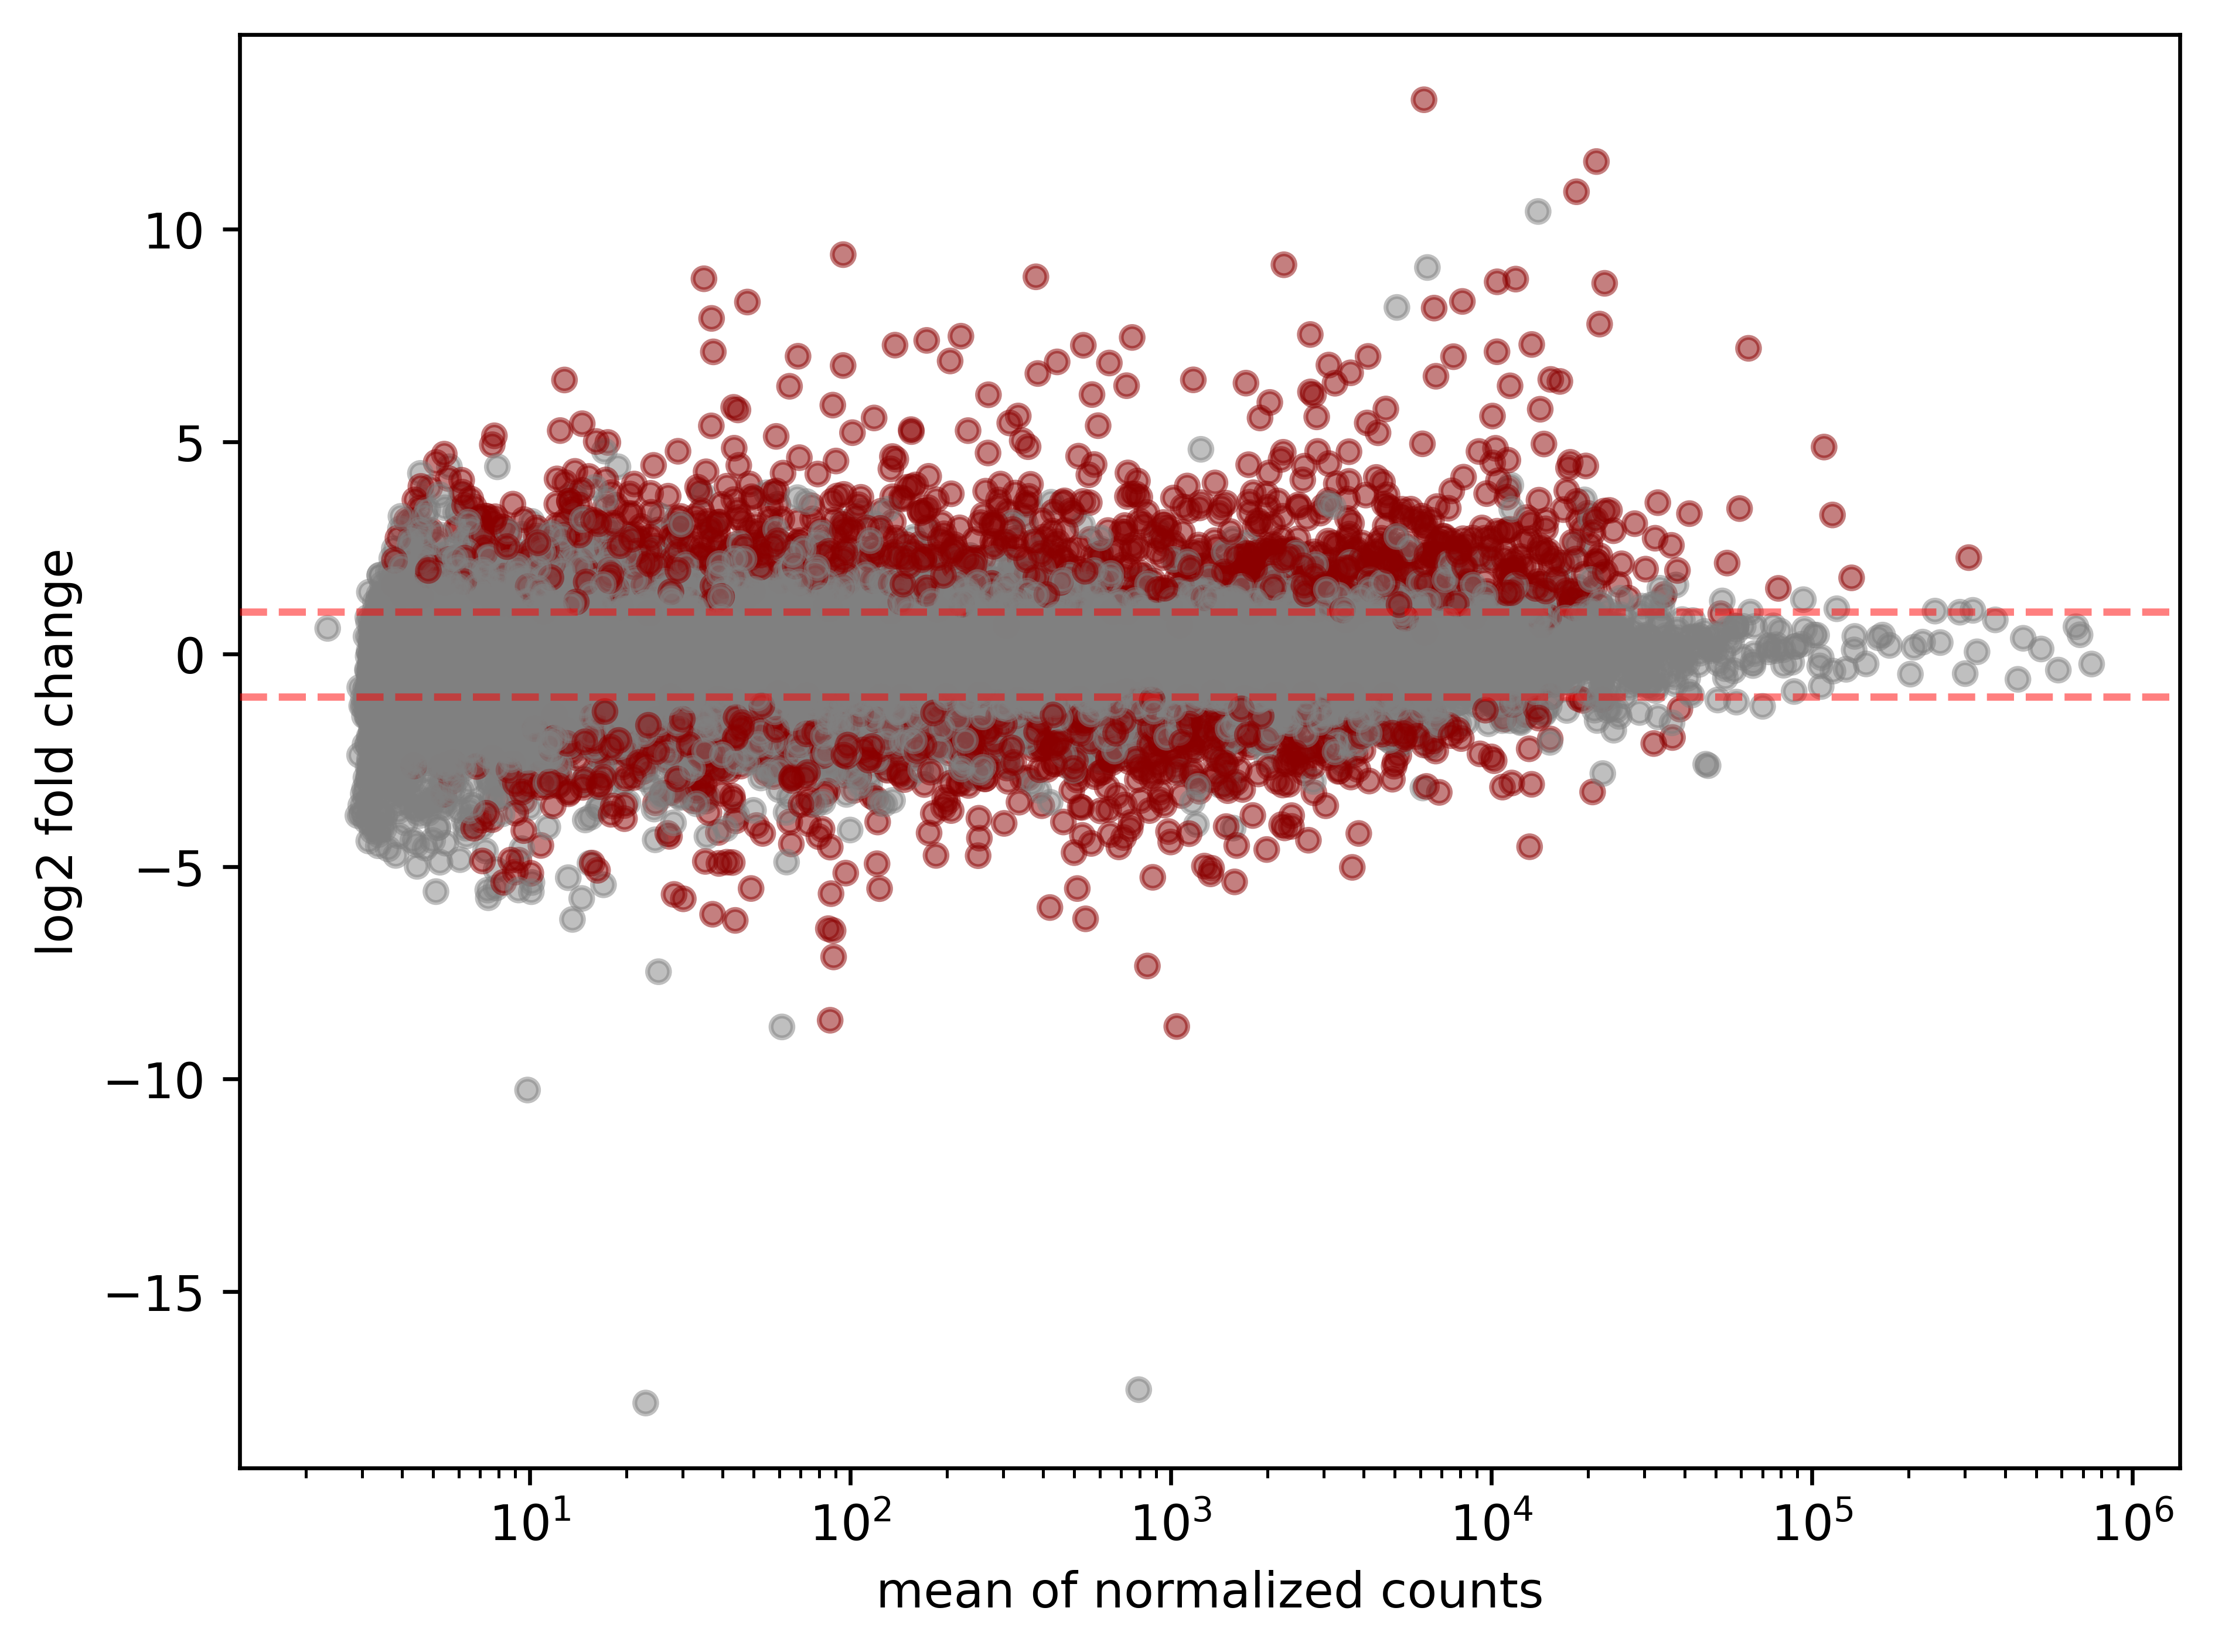

In [79]:
ds.summary(lfc_null=1.0, alt_hypothesis="greaterAbs")
ds.plot_MA(s=20)

In [80]:
ds.results_df


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,9.956286,0.085215,0.538449,0.000000,1.000000,1.000000
ENSG00000000419,1379.172068,0.052771,0.095846,0.000000,1.000000,1.000000
ENSG00000000457,622.457651,1.053680,0.184366,0.885006,0.376153,1.000000
ENSG00000000460,277.491174,-0.246541,0.102493,0.000000,1.000000,1.000000
ENSG00000000938,17463.998981,-0.123511,0.213993,0.000000,1.000000,1.000000
...,...,...,...,...,...,...
ENSG00000288580,3.384842,0.298171,0.536375,0.000000,1.000000,NaN
ENSG00000288582,23.761106,-0.031371,0.480049,0.000000,1.000000,1.000000
ENSG00000288586,40.039772,-0.692699,0.333905,-1.519586,0.128615,0.689274


In [81]:
# Filter significant genes based on adjusted p-value and log2 fold change
significant_genes = ds.results_df[
    (ds.results_df["padj"] < 0.05) & 
    (abs(ds.results_df["log2FoldChange"]) > 1.0)]

# Display the filtered significant genes
print(significant_genes)


                     baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                              
ENSG00000000971     33.396337        3.930357  0.486349   6.183654   
ENSG00000002549  24976.423693        1.644200  0.395334   4.159019   
ENSG00000002587    251.907619       -3.860841  0.618201  -3.756197   
ENSG00000003400   1641.824554        2.044330  0.067015  10.332563   
ENSG00000003402  24024.183118        2.906952  0.119311  16.421623   
...                       ...             ...       ...        ...   
ENSG00000288065     17.933251       -2.189507  0.437402  -3.767697   
ENSG00000288156     70.223295       -3.536457  0.611948  -5.779013   
ENSG00000288187     14.862707       -2.061071  0.472263  -3.559631   
ENSG00000288302     17.172905       -1.348386  0.444205  -3.035507   
ENSG00000288380     73.562788       -2.785805  0.488460  -3.671747   

                       pvalue          padj  
gene_id                                    

In [82]:
# Map gene names to the index of significant_genes
significant_genes["gene_name"] = significant_genes.index.map(gene_symbols.to_dict())

# Display the updated DataFrame
print(significant_genes.head())

                     baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                              
ENSG00000000971     33.396337        3.930357  0.486349   6.183654   
ENSG00000002549  24976.423693        1.644200  0.395334   4.159019   
ENSG00000002587    251.907619       -3.860841  0.618201  -3.756197   
ENSG00000003400   1641.824554        2.044330  0.067015  10.332563   
ENSG00000003402  24024.183118        2.906952  0.119311  16.421623   

                       pvalue          padj gene_name  
gene_id                                                
ENSG00000000971  6.263456e-10  3.767222e-08       CFH  
ENSG00000002549  3.196167e-05  7.498288e-04      LAP3  
ENSG00000002587  1.725149e-04  3.211499e-03    HS3ST1  
ENSG00000003400  5.020077e-25  7.217325e-23    CASP10  
ENSG00000003402  1.339363e-60  3.851184e-58     CFLAR  


/var/folders/cd/fyn3h6dn31jb9cq7w2h7nrmh0000gn/T/ipykernel_46179/1354614600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_genes["gene_name"] = significant_genes.index.map(gene_symbols.to_dict())


## Save Results

In [83]:
# Save the filtered significant genes to a CSV file
significant_genes.to_csv("data/significant_genes_filtered.csv", index=False)


## Summary

This workflow covers the following steps:
1. Data loading, processing and normalization.
2. Metadata incorporation.
3. Differential expression analysis using DESeq2.
4. Saving the results.